**Homework 3**

*Instructions:* Please complete the following project and submit your solution by the next class session.

1. Download daily returns for at least 100 constituents of the S&P 500 index over the period 2010–2025.

2. Compute the sample covariance matrix and perform a PCA on the returns.

3. Analyze the results:
    - Comment on the leading principal components.

    - Plot the cumulative explained variance as a function of the number of components.

4. Bonus ([Marcenko-Pastur](https://en.wikipedia.org/wiki/Marchenko%E2%80%93Pastur_distribution)):

    - Recall the Marcenko-Pastur distribution and its parameters.

    - Compare the empirical eigenvalue distribution of the covariance matrix to the Marcenko-Pastur distribution:
        - Estimate the theoretical support.
        
        - Identify which eigenvalues deviate from the bulk and interpret them.

In [1]:
import yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Download daily returns for at least 100 constituents of the S&P 500 index over the period 2010–2025.
tickers = yfinance.Tickers(
    "AAPL MSFT GOOGL AMZN META TSLA JPM V J WMT PG MA NVDA DIS HD BAC VZ UNH CVX PFE "
    "KO MRK ABT T MO NKE ORCL INTC CSCO CMCSA XOM PEP ADBE CRM NFLX PYPL TSM BMY LLY "
    "MDT UNP UPS C COST MCD IBM QCOM TXN HON SBUX CAT GE MMM AMGN GILD FISV ADP BKNG "
    "SPGI DE LRCX SYK ZTS CL FIS MU EA ISRG REGN ILMN ADI LULU MAR SYY AXP BLK SCHW "
    "USB GD FDX ECL APD DHR EXC AON CLX EOG HCA KMB CCI AIG COP ETR SRE NEE PLD DUK "
    "SO WFC AEP D TEVA CSX EIX PSX VLO ALL HLT ROP CTAS NOC STZ KKR MCO APTV ANET "
    "EBAY MNST OXY DVN APA ALGN SWKS VRSN DXCM MCHP PAYX FAST CDNS NTAP SNPS VRTX "
    "BIIB CAG FRT ESS NVR RMD MTCH WRB ODFL CINF TRV HIG MAA AVGO RCL GPN NEM BDX "
    "EFX JCI PGR AZO"
)
data = tickers.history(start="2010-01-01", end="2025-12-31")["Close"]


[*********************100%***********************]  154 of 154 completed


In [3]:
data.head()
data.info()
data.describe()
data.shape

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4023 entries, 2010-01-04 to 2025-12-30
Columns: 154 entries, AAPL to ZTS
dtypes: float64(154)
memory usage: 4.8 MB


(4023, 154)

In [4]:
#  Compute the sample covariance matrix and perform a PCA on the returns.
returns = data.pct_change(fill_method=None).dropna()
cov_matrix = np.cov(returns, rowvar=False)
U, S, U_transpose = np.linalg.svd(cov_matrix)
explained_variance = S / np.sum(S)


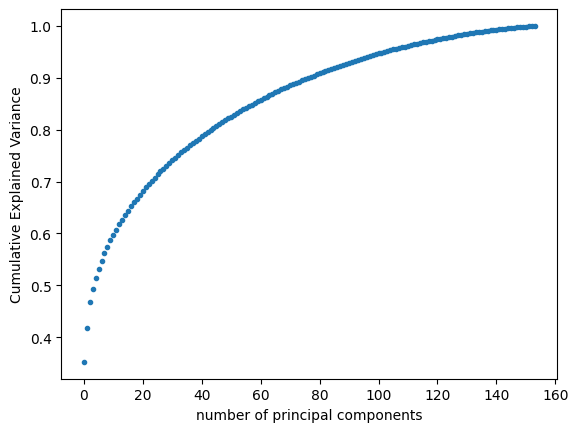

In [5]:
fig, ax = plt.subplots()
ax.plot(np.arange(len(explained_variance)), np.cumsum(explained_variance), ".")
ax.set_xlabel("number of principal components")
ax.set_ylabel("Cumulative Explained Variance")
plt.show()

In [7]:
# print summary statistics
print(
    f"First 3 components explain {np.sum(explained_variance[:3])*100:.2f}% of variance"
)
print(
    "Components needed for 95% variance: "
    f"{np.argmax(np.cumsum(explained_variance) >= 0.95) + 1}"
)
print(
    "Components needed for 99% variance: "
    f"{np.argmax(np.cumsum(explained_variance) >= 0.99) + 1}"
)

First 3 components explain 46.75% of variance
Components needed for 95% variance: 103
Components needed for 99% variance: 138


In [11]:
n_components = 3
ticker_names = returns.columns.tolist()

for i in range(n_components):
    loadings = pd.Series(U[:, i], index=ticker_names).sort_values()
    print(f"\n=== PC{i+1} (explains {explained_variance[i]*100:.1f}% of variance) ===")
    print("Top 5 positive loadings:")
    print(loadings.tail(5).to_string())
    print("Top 5 negative loadings:")
    print(loadings.head(5).to_string())



=== PC1 (explains 35.2% of variance) ===
Top 5 positive loadings:
NEM   -0.032302
VZ    -0.032004
CAG   -0.031460
KMB   -0.031156
CLX   -0.021612
Top 5 negative loadings:
APA    -0.141360
RCL    -0.140729
MU     -0.131350
LRCX   -0.131131
DVN    -0.130447

=== PC2 (explains 6.6% of variance) ===
Top 5 positive loadings:
CDNS    0.128528
SNPS    0.128940
NFLX    0.151083
TSLA    0.157256
NVDA    0.206124
Top 5 negative loadings:
APA   -0.310886
DVN   -0.271737
OXY   -0.267448
EOG   -0.222703
COP   -0.211035

=== PC3 (explains 4.9% of variance) ===
Top 5 positive loadings:
NVDA    0.167627
TSLA    0.167984
MU      0.187989
DVN     0.208425
APA     0.240106
Top 5 negative loadings:
D     -0.159360
SO    -0.151773
DUK   -0.150833
AEP   -0.149669
NEE   -0.136762


**PC1 — Market Factor**: All stocks load with the same sign, capturing broad market co-movement. Defensive stocks (consumer staples, telecom) have smaller loadings while cyclicals (energy, semiconductors) have larger ones.

**PC2 — Growth Tech vs. Energy**: Contrasts high-growth technology stocks (NVDA, TSLA, NFLX) against oil & gas companies (APA, DVN, OXY), reflecting the growth/value rotation most pronounced in 2020–2022.

**PC3 — Risk-On vs. Utilities**: Separates high-volatility cyclicals from rate-sensitive utility stocks, capturing shifts in investor risk appetite.


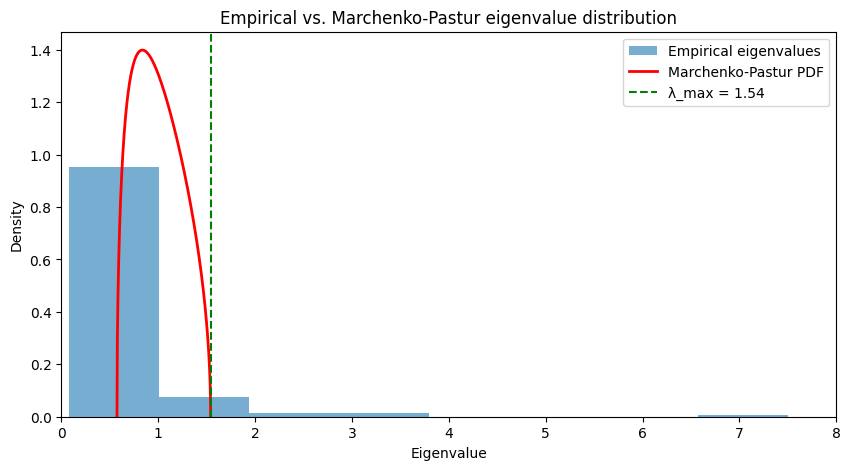

N=154, T=2636, q=0.0584
MP support: [0.5750, 1.5418]
Eigenvalues above λ_max (signal): 10
[55.735  9.28   7.401  3.351  2.891  2.439  2.041  1.847  1.69   1.566]


In [12]:
# ── Bonus: Marchenko-Pastur ──────────────────────────────────────
N = returns.shape[1]   # 154 stocks
T = returns.shape[0]   # number of trading days
q = N / T
sigma_sq = 1.0  # correlation matrix → σ²=1

# Eigenvalues of the correlation matrix
corr_matrix = np.corrcoef(returns, rowvar=False)
eigvals = np.sort(np.linalg.eigvalsh(corr_matrix))[::-1]

# MP theoretical support
lam_min = sigma_sq * (1 - np.sqrt(q))**2
lam_max = sigma_sq * (1 + np.sqrt(q))**2

# MP PDF
lam_grid = np.linspace(lam_min, lam_max, 500)
mp_pdf = (1 / (2 * np.pi * sigma_sq * q * lam_grid)) * np.sqrt(
    (lam_max - lam_grid) * (lam_grid - lam_min)
)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(eigvals, bins=60, density=True, alpha=0.6, label="Empirical eigenvalues")
ax.plot(lam_grid, mp_pdf, "r-", linewidth=2, label="Marchenko-Pastur PDF")
ax.axvline(lam_max, color="green", linestyle="--",
           label=f"λ_max = {lam_max:.2f}")
ax.set_xlim(0, 8)   # zoom in on the bulk; signal spikes are far right
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Density")
ax.set_title("Empirical vs. Marchenko-Pastur eigenvalue distribution")
ax.legend()
plt.show()

# Identify signal eigenvalues
signal = eigvals[eigvals > lam_max]
print(f"N={N}, T={T}, q={q:.4f}")
print(f"MP support: [{lam_min:.4f}, {lam_max:.4f}]")
print(f"Eigenvalues above λ_max (signal): {len(signal)}")
print(signal.round(3))


**Marchenko-Pastur Analysis**

With N=154 stocks and T=2636 trading days, the ratio q = N/T ≈ 0.0584.
Under the null hypothesis of pure noise, the Marchenko-Pastur distribution
predicts eigenvalues confined to [λ_min, λ_max] = [0.575, 1.542].

We find **10 eigenvalues** exceeding λ_max, indicating 10 genuine systematic
factors in the data:

- The dominant eigenvalue (55.74) is far above the bulk and corresponds to
  **PC1 — the market factor**, capturing broad co-movement across all stocks.
- The next eigenvalues (9.28, 7.40, 3.35, ...) correspond to **sector factors**
  such as the growth/energy rotation (PC2) and the cyclical/utilities split (PC3)
  identified above.
- The remaining 144 eigenvalues fall within the MP bulk and are
  indistinguishable from random noise.

This suggests that only ~6.5% of the 154 principal components carry genuine
information, while the rest reflect sampling noise.
